In [13]:
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from tqdm import tqdm
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load models 

In [7]:
BASE_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC"

from hydra import initialize, compose
import os
import sys
import logging
from labcompass.constants import DataFields
import torch.nn.functional as F


sys.path.insert(0, os.path.join(BASE_DIR, "shared_utils"))

from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn, 
    compute_exploitation_score, 
    compute_exploration_score, 
    compute_weighted_uncertainty_score, 
    compute_sequential_local_penalization
)

In [8]:
CONFIG_PATH = "../../../../config"

with initialize(config_path=CONFIG_PATH, version_base=None):
    base_cfg = compose(
        config_name="run_inverse",
        overrides=["paths=bloodplus_fm"]
    )

In [9]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [10]:
forward_model, (_, target_prediction_model) = get_forward_model(base_cfg, logger=logger)

2026-05-07 13:30:17,888 - INFO - Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...
2026-05-07 13:32:02,341 - INFO - Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
   

In [11]:
# Prepare label encoder
logger.info("Preparing labels")   
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()  # List of cell types in alphabetical order 

2026-05-07 13:32:04,866 - INFO - Preparing labels


# Read annotation file 

In [15]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [30]:
# Paths to load 
generated_csvs_paths = {
    "EryPro": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus/filtered/filtered_candidates_EryPro.csv", 
    "late_MgkPro": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus/filtered/filtered_candidates_late_MgkPro.csv"
}

Load generated files

In [31]:
generated_csvs = {}

for cell_type in generated_csvs_paths:
    generated_csvs[cell_type] = pd.read_csv(generated_csvs_paths[cell_type], index_col=0).loc[:, protocol_cols]

Load unique concentrations

In [33]:
unique_concentrations = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/miscellaneous/unique_concentrations_adata_bloodplus.h5ad")
unique_concentrations.X = np.exp(unique_concentrations.X) - 1
print(unique_concentrations.X)

[[  5. 100.  10. ...   0.  20.  13.]
 [  5. 100.  10. ...   0.  20.  15.]
 [  5. 100.  10. ...   0.  20.  21.]
 ...
 [  5. 100.  10. ...   0.  20.  21.]
 [  5. 100.  10. ...   0.  20.  14.]
 [  5. 100.  10. ...   0.  20.  21.]]


In [34]:
def predict_cell_type_probs(
    df: pd.DataFrame,
    forward_model,
    classes,
    n_noise_samples: int = 32,
    num_time_steps: int = 100,
):
    # Move candidates to correct device
    X_candidates = torch.from_numpy(df.values).float().to(
        forward_model.forward_model.device
    )
    X_candidates = torch.log1p(X_candidates)

    # Expand for noise samples
    X_candidates_add = (
        X_candidates.unsqueeze(1)
        .repeat(1, n_noise_samples, 1)
    )

    # Build batch dictionary
    condition_repr = next(
        iter(
            forward_model.forward_model.train_data.data
            .perturbation_covariates
        )
    )

    batch_dict = {
        DataFields.PERTURBATION_DATA: {
            condition_repr: X_candidates_add
        }
    }

    with torch.no_grad():
        # Forward prediction
        forward_out = forward_model.predict(
            batch_dict,
            no_grad=True,
            fix_noise=False,
            num_time_steps=num_time_steps,
        )
    
        # Average probabilities across noise samples
        y_pred = F.softmax(
            forward_out["target_prediction_data"]["cell_type"],
            dim=-1,
        ).mean(1)
    
        # Convert to dataframe
        pred_df = pd.DataFrame(
            y_pred.cpu().numpy(),
            columns=classes,
        )
    return pred_df

def sensitivity_multiple_columns(model, df, real_concentrations, n_grid, columns, cell_type):
    df_zeros = df.copy()
    df_zeros.loc[:, columns] = 0
    
    # Get columns max values 
    linspaces = {}
    for col in columns:
        column_max = real_concentrations[:, col].X.max()
        linspaces[col] = np.linspace(0, column_max, 10)
    
    # Apply to dataframe 
    cell_type_prop_pred  = {col: {"Units": [], "Value": [], "cell_type_prop": []} for col in linspaces}
    
    for col in linspaces:
        for val in linspaces[col]:
            df_mod = df_zeros.copy()
            df_mod.loc[:, col] = val
            
            # Run predictions
            y_pred = predict_cell_type_probs(
                df_mod,
                model, 
                classes,
                n_noise_samples = 350,
                num_time_steps = 100)

            y_pred_ct = y_pred.loc[:, cell_type]
            cell_type_prop_pred[col]["cell_type_prop"] += list(y_pred_ct)
            cell_type_prop_pred[col]["Value"] += [val for _ in range(len(y_pred_ct))]
            cell_type_prop_pred[col]["Units"] += list(range(len(y_pred_ct)))

    # cell_type_prop_pred = {key: pd.DataFrame(val) for key,val in cell_type_prop_pred.items()}
    return cell_type_prop_pred

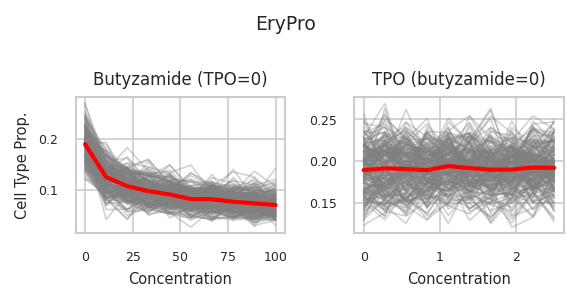

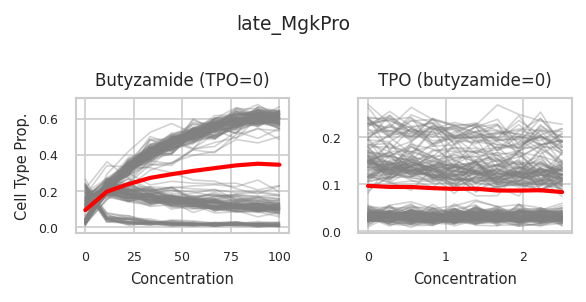

In [35]:
sns.set_style("whitegrid")
sns.set_context("paper")

for cell_type in generated_csvs:

    cell_type_prop_pred = sensitivity_multiple_columns(
        forward_model,
        generated_csvs[cell_type],
        unique_concentrations,
        10,
        ["butyzamide_[nm]", "tpo_[ng_ml]"],
        cell_type
    )

    fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=150)

    # =========================
    # Butyzamide
    # =========================

    # Individual trajectories
    sns.lineplot(
        data=cell_type_prop_pred["butyzamide_[nm]"],
        x="Value",
        y="cell_type_prop",
        units="Units",
        estimator=None,
        alpha=0.35,
        linewidth=0.8,
        color="gray",
        ax=axes[0],
    )

    # Mean trajectory
    sns.lineplot(
        data=cell_type_prop_pred["butyzamide_[nm]"],
        x="Value",
        y="cell_type_prop",
        errorbar=None,
        estimator="mean",
        color="red",
        linewidth=2,
        ax=axes[0],
    )

    axes[0].set_title("Butyzamide (TPO=0)", fontsize=8)
    axes[0].set_xlabel("Concentration", fontsize=7)
    axes[0].set_ylabel("Cell Type Prop.", fontsize=7)
    axes[0].tick_params(labelsize=6)

    # =========================
    # TPO
    # =========================

    # Individual trajectories
    sns.lineplot(
        data=cell_type_prop_pred["tpo_[ng_ml]"],
        x="Value",
        y="cell_type_prop",
        units="Units",
        estimator=None,
        alpha=0.35,
        linewidth=0.8,
        color="gray",
        ax=axes[1],
    )

    # Mean trajectory
    sns.lineplot(
        data=cell_type_prop_pred["tpo_[ng_ml]"],
        x="Value",
        y="cell_type_prop",
        errorbar=None,
        estimator="mean",
        color="red",
        linewidth=2,
        ax=axes[1],
    )

    axes[1].set_title("TPO (butyzamide=0)", fontsize=8)
    axes[1].set_xlabel("Concentration", fontsize=7)
    axes[1].set_ylabel("")
    axes[1].tick_params(labelsize=6)

    # Main title
    fig.suptitle(cell_type, fontsize=9)

    plt.tight_layout()
    plt.show()

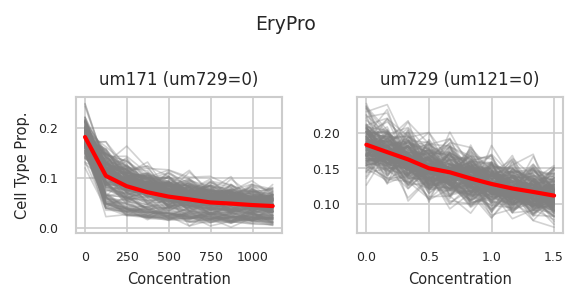

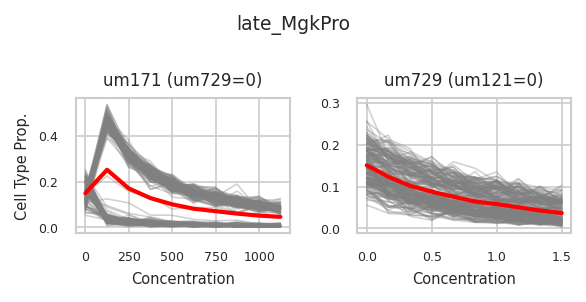

In [36]:
# Optional: cleaner global style
sns.set_style("whitegrid")
sns.set_context("paper")


for cell_type in generated_csvs:

    cell_type_prop_pred = sensitivity_multiple_columns(
        forward_model,
        generated_csvs[cell_type],
        unique_concentrations,
        10,
        ["um171_[nm]", "um729_[µm]"],
        cell_type
    )

    fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=150)

    # =========================
    # Butyzamide
    # =========================

    # Individual trajectories
    sns.lineplot(
        data=cell_type_prop_pred["um171_[nm]"],
        x="Value",
        y="cell_type_prop",
        units="Units",
        estimator=None,
        alpha=0.35,
        linewidth=0.8,
        color="gray",
        ax=axes[0],
    )

    # Mean trajectory
    sns.lineplot(
        data=cell_type_prop_pred["um171_[nm]"],
        x="Value",
        y="cell_type_prop",
        errorbar=None,
        estimator="mean",
        color="red",
        linewidth=2,
        ax=axes[0],
    )

    axes[0].set_title("um171 (um729=0)", fontsize=8)
    axes[0].set_xlabel("Concentration", fontsize=7)
    axes[0].set_ylabel("Cell Type Prop.", fontsize=7)
    axes[0].tick_params(labelsize=6)

    # =========================
    # TPO
    # =========================

    # Individual trajectories
    sns.lineplot(
        data=cell_type_prop_pred["um729_[µm]"],
        x="Value",
        y="cell_type_prop",
        units="Units",
        estimator=None,
        alpha=0.35,
        linewidth=0.8,
        color="gray",
        ax=axes[1],
    )

    # Mean trajectory
    sns.lineplot(
        data=cell_type_prop_pred["um729_[µm]"],
        x="Value",
        y="cell_type_prop",
        errorbar=None,
        estimator="mean",
        color="red",
        linewidth=2,
        ax=axes[1],
    )

    axes[1].set_title("um729 (um121=0)", fontsize=8)
    axes[1].set_xlabel("Concentration", fontsize=7)
    axes[1].set_ylabel("")
    axes[1].tick_params(labelsize=6)

    # Main title
    fig.suptitle(cell_type, fontsize=9)

    plt.tight_layout()
    plt.show()